In [ ]:
from IPython.display import Image
Image(url="https://media4.giphy.com/media/v1.Y2lkPTc5MGI3NjExOWxnYmhvdmVpeDM3dG94bDJ0b3FucGZiOTBiZ280OXVmZGZsaGVldSZlcD12MV9pbnRlcm5hbF9naWZfYnlfaWQmY3Q9Zw/3ycWZKbmWwttCe95Mz/giphy.gif")

#Question:
“Does the position of the Super Bowl MVP help predict the point difference in the Super Bowl?”

Sub Question: The purpose of seeing if QB MVPs happen in closer games or if defensive MVPs happen in blowouts.

In [ ]:
import pandas as pd
import numpy as np
import re

from datetime import datetime, date, timezone
from dateutil.parser import parse

import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("seaborn-v0_8-notebook")
plt.rcParams["figure.figsize"] = (8, 6)

In [ ]:
from google.colab import drive
drive.mount("/content/gdrive/")

Mounted at /content/gdrive/


In [ ]:
df = pd.read_csv("/content/gdrive/My Drive/Colab Notebooks/Tas 300/SuperBowl_Standings.csv")

In [ ]:
df = pd.read_csv("/content/gdrive/My Drive/Colab Notebooks/Tas 300/SuperBowl_Leaderboard.csv")


In [ ]:
df = pd.read_csv("/content/gdrive/My Drive/Colab Notebooks/Tas 300/SuperBowl_History.300 - SuperBowl_History.csv")
pd.set_option("display.max_columns", None)

df

,Date,SB,Winner,WinPts,Loser,LosePts,MVP,Stadium,City,State
0,Feb 9 2025,LIX (59),Philadelphia Eagles,40,Kansas City Chiefs,22,Jalen Hurts (O),Caesars Superdome,New Orleans,Louisiana
1,Feb 11 2024,LVIII (58),Kansas City Chiefs,25,San Francisco 49ers,22,Patrick Mahomes (O),Allegiant Stadium,Las Vegas,Nevada
2,Feb 12 2023,LVII (57),Kansas City Chiefs,38,Philadelphia Eagles,35,Patrick Mahomes (O),State Farm Stadium,Glendale,Arizona
3,Feb 13 2022,LVI (56),Los Angeles Rams,23,Cincinnati Bengals,20,Cooper Kupp (O),SoFi Stadium,Inglewood,California
4,Feb 7 2021,LV (55),Tampa Bay Buccaneers,31,Kansas City Chiefs,9,Tom Brady (O),Raymond James Stadium,Tampa,Florida
5,Feb 2 2020,LIV (54),Kansas City Chiefs,31,San Francisco 49ers,20,Patrick Mahomes (O),Hard Rock Stadium,Miami Gardens,Florida
6,Feb 3 2019,LIII (53),New England Patriots,13,Los Angeles Rams,3,Julian Edelman (O),Mercedes-Benz Stadium,Atlanta,Georgia
7,Feb 4 2018,LII (52),Philadelphia Eagles,41,New England Patriots,33,Nick Foles (O),U.S. Bank Stadium,Minneapolis,Minnesota
8,Feb 5 2017,LI (51),New England Patriots,34,Atlanta Falcons,28,Tom Brady(O),NRG Stadium,Houston,Texas
9,Feb 7 2016,L (50),Denver Broncos,24,Carolina Panthers,10,Von Miller (D),Levi's Stadium,Santa Clara,California


In [ ]:
new_df = df.copy()

In [ ]:
new_df = df[["Loser","LosePts","Date","SB","Winner"]]
df.head(5)

,Date,SB,Winner,WinPts,Loser,LosePts,MVP,Stadium,City,State
0,Feb 9 2025,LIX (59),Philadelphia Eagles,40,Kansas City Chiefs,22,Jalen Hurts (O),Caesars Superdome,New Orleans,Louisiana
1,Feb 11 2024,LVIII (58),Kansas City Chiefs,25,San Francisco 49ers,22,Patrick Mahomes (O),Allegiant Stadium,Las Vegas,Nevada
2,Feb 12 2023,LVII (57),Kansas City Chiefs,38,Philadelphia Eagles,35,Patrick Mahomes (O),State Farm Stadium,Glendale,Arizona
3,Feb 13 2022,LVI (56),Los Angeles Rams,23,Cincinnati Bengals,20,Cooper Kupp (O),SoFi Stadium,Inglewood,California
4,Feb 7 2021,LV (55),Tampa Bay Buccaneers,31,Kansas City Chiefs,9,Tom Brady (O),Raymond James Stadium,Tampa,Florida


Below, I had a vision of using a heat map I beleive its called to answer the question and it would highlight the answer right in the middle. My theory the higher the oint difference is means its more likely the mvp would be a defensive player.

In [ ]:
df["point_difference"] = df["WinPts"] - df["LosePts"]
df.head(5)

,Date,SB,Winner,WinPts,Loser,LosePts,MVP,Stadium,City,State,point_difference
0,Feb 9 2025,LIX (59),Philadelphia Eagles,40,Kansas City Chiefs,22,Jalen Hurts (O),Caesars Superdome,New Orleans,Louisiana,18
1,Feb 11 2024,LVIII (58),Kansas City Chiefs,25,San Francisco 49ers,22,Patrick Mahomes (O),Allegiant Stadium,Las Vegas,Nevada,3
2,Feb 12 2023,LVII (57),Kansas City Chiefs,38,Philadelphia Eagles,35,Patrick Mahomes (O),State Farm Stadium,Glendale,Arizona,3
3,Feb 13 2022,LVI (56),Los Angeles Rams,23,Cincinnati Bengals,20,Cooper Kupp (O),SoFi Stadium,Inglewood,California,3
4,Feb 7 2021,LV (55),Tampa Bay Buccaneers,31,Kansas City Chiefs,9,Tom Brady (O),Raymond James Stadium,Tampa,Florida,22


In [ ]:
df["HoF"] = df["MVP"].str.endswith("+")
Yes = df["MVP"].str.endswith("+", na = False)
hof_column = df.pop("HoF")
df.insert(loc=2, column="HoF", value=hof_column)

This cell just creates a collumn that puts HOF players into their own catagory.

In [ ]:
df["Offense"] = df["MVP"].str.endswith("(O)")
df["Deffense"] = df["MVP"].str.endswith("(D)")
Yes = df["MVP"].str.endswith("+", na = False)
Offense_column = df.pop("Offense")
Deffense_column = df.pop("Deffense")
df.insert(loc=2, column="Offense", value=Offense_column)
df.insert(loc=3, column="Deffense", value=Deffense_column)

Since my question is more player and postion based I had to create a whole new collumn stating if the player is on offense or deffense. I dont really know football like at all so this took some research for me. I used the same code for creating a hof catagory as this one just a little remix of it.

In [ ]:
df.head(2)

,Date,SB,Offense,Deffense,HoF,Winner,WinPts,Loser,LosePts,MVP,Stadium,City,State,point_difference
0,Feb 9 2025,LIX (59),True,False,False,Philadelphia Eagles,40,Kansas City Chiefs,22,Jalen Hurts (O),Caesars Superdome,New Orleans,Louisiana,18
1,Feb 11 2024,LVIII (58),True,False,False,Kansas City Chiefs,25,San Francisco 49ers,22,Patrick Mahomes (O),Allegiant Stadium,Las Vegas,Nevada,3


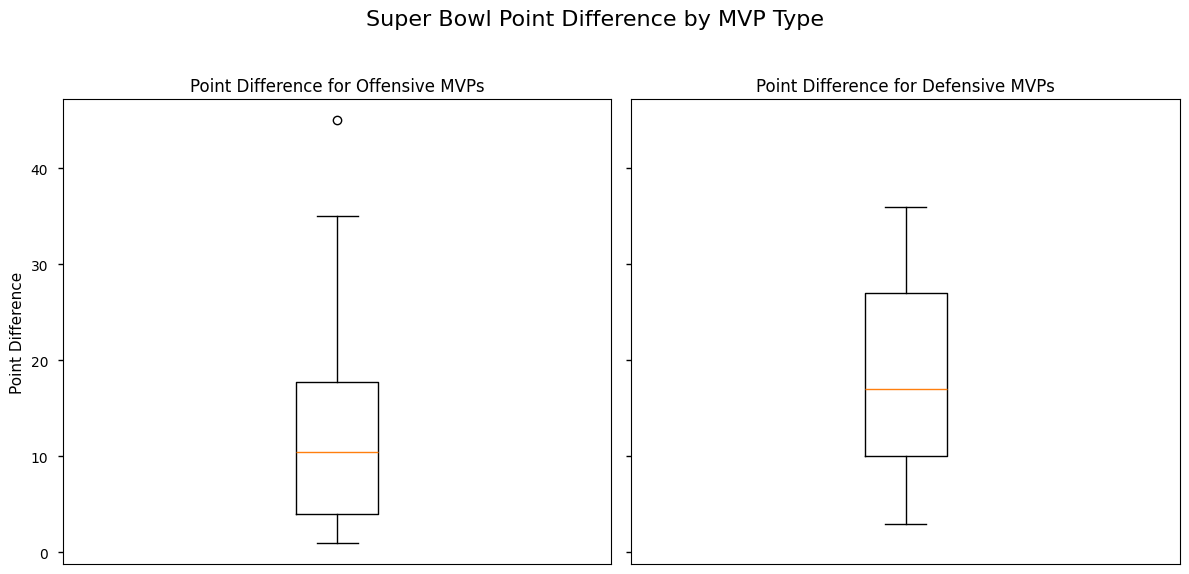

In [ ]:
offensive_mvp_diff = df[df['Offense']]['point_difference']
defensive_mvp_diff = df[df['Deffense']]['point_difference']

fig, (ax1, ax2) = plt.subplots(nrows=1,
                               ncols=2,
                               figsize=(12, 6),
                               sharey=True)

ax1.set_title('Point Difference for Offensive MVPs')
ax1.set_ylabel('Point Difference')
ax1.boxplot(offensive_mvp_diff)
ax1.set_xticks([])

ax2.set_title('Point Difference for Defensive MVPs')
ax2.boxplot(defensive_mvp_diff)
ax2.set_xticks([])

plt.suptitle('Super Bowl Point Difference by MVP Type', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

#Question: “Does the position of the Super Bowl MVP help predict the point difference in the Super Bowl?

#Offensive Side
 Lets start off on the offensivie side of the ball, It seems to me that via the graph the minimum point difference needed to win MVP is closer to 3 more than zero while the maximum is 30-40 meaning such as 35. Which since I think it's way above the boz it could even be considered an outlier . Although there is a dot which is way above the box which will neeed some investigation. Overall the box Q1,2 and 3 are much lower than the defensive side showing a downward shift in point difference. You can also tell by the median point difference being just on the closer end of 10 then 20. So you can draw the conclusion that on average offensive MVPs do happen in closer games

#Defensive Side
The minimum sore needed was somewhere less than 10 while , the maximum needed was somewhere between 30-40. The Q1 appears alot higher than it would on the offensive side of the ball, in fact you can even say the Q1 occurs around the median average point difference of the offensive side of the ball. Which means on average the point difference has to be higher for a Defensive MVP especially since the interquartile range is much longer of deffense. I would say the median is within the lower quartile which would point to most of the data being on the lower end of the box. Since Q3 is higher that just means theres still some good data that was collected before becoming the maxium which would be good for this predictive of a model.

#

In [ ]:
mean_offensive_diff = offensive_mvp_diff.mean()
mean_defensive_diff = defensive_mvp_diff.mean()

print(f"Mean point difference for Offensive MVPs: {mean_offensive_diff:.2f}")
print(f"Mean point difference for Defensive MVPs: {mean_defensive_diff:.2f}")

Mean point difference for Offensive MVPs: 12.48
Mean point difference for Defensive MVPs: 19.56


Here below is the average point difference between offensive and defensive mvps, So in conclusion defensive MVPs happen in lare score differential games then offensive MVPs

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
k = KNeighborsClassifier()
k.fit(X_train, y_train)
y_pred_k = k.predict(X_test)

Confusion Matrix (Predicting MVP Type from Point Difference - Resampled Data):
[[9 6]
 [1 2]]


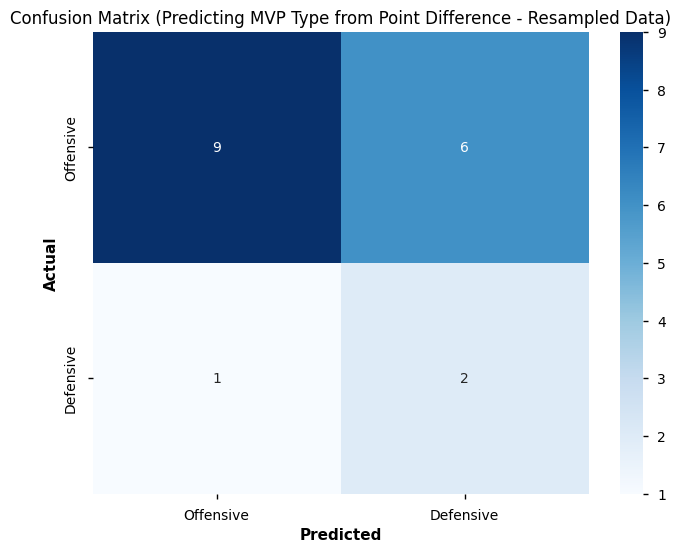

Accuracy (Resampled): 0.6111
Precision (Resampled): 0.5750
Recall (Resampled): 0.6333
F1-Score (Resampled): 0.5418


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
import seaborn as sns


k_mvp_pred_resampled = KNeighborsClassifier()
k_mvp_pred_resampled.fit(X_train_mvp_resampled, y_train_mvp_resampled)
y_pred_mvp_resampled = k_mvp_pred_resampled.predict(X_test_mvp)


class_labels_mvp = y_test_mvp.unique()
cm_mvp_resampled = confusion_matrix(y_test_mvp, y_pred_mvp_resampled, labels=class_labels_mvp)

print("Confusion Matrix (Predicting MVP Type from Point Difference - Resampled Data):")
print(cm_mvp_resampled)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_mvp_resampled, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_labels_mvp,
            yticklabels=class_labels_mvp)

plt.xlabel("Predicted", weight="bold")
plt.ylabel("Actual", weight="bold")
plt.title("(Predicting MVP Type from Point Difference)")
plt.show()

accuracy_mvp_resampled = accuracy_score(y_test_mvp, y_pred_mvp_resampled)
precision_mvp_resampled, recall_mvp_resampled, f1_score_mvp_resampled, _ = precision_recall_fscore_support(y_test_mvp, y_pred_mvp_resampled, average="macro", zero_division=1)

print(f"Accuracy (Resampled): {accuracy_mvp_resampled:.4f}")
print(f"Precision (Resampled): {precision_mvp_resampled:.4f}")
print(f"Recall (Resampled): {recall_mvp_resampled:.4f}")
print(f"F1-Score (Resampled): {f1_score_mvp_resampled:.4f}")

This model crrectly identifys 9 offensive MVPs and only 2 defensive mvps. Although the DMVP are much more harder to predict since their point difference overlaps quite a bit with the offensive MVPS. So for this overlap the model mistaked 6 OMVPs for DMVPs which makes sense considering a close point difference and seeing as the model accuracy isnt 100%.